In [1]:
import gc
# import torch

gc.collect()
# torch.cuda.empty_cache()
# torch.cuda.ipc_collect()

import os
os.listdir(); os.chdir("/aiau010_scratch/azm0269/clover/")

from clover.utils.utils import notebook_line_magic
notebook_line_magic()

In [2]:
import json
from pathlib import Path
import pandas as pd
import numpy as np

current_baselines = ["emo", "emo_v2", "emo_v3", "emo_v3_old", "ddpo", "b2diffurl"] 
baselines = ["md3po", "emo", "emo_v2", "emo_v3", "emo_v3_old", "ddpo", "b2diffurl", "dpok"]
eval_path = Path("outputs/")
training_data_eval_file = "training_metrics.json"
evaluation_data_eval_file = "eval_metrics.json"

def get_training_metrics_df(file_path):
    if file_path.exists():
        with open(file_path, "r") as f:
            list_of_metrics = json.load(f)
    else:
        print(f"File {file_path} does not exist. Skipping.")
        return pd.DataFrame()  # Return an empty DataFrame if the file doesn't exist
    all_metric_entries = []
    for entry in list_of_metrics:
        all_metric_entries.append(entry['metrics'])
    df = pd.DataFrame(all_metric_entries)
    return df

def get_eval_metrics_df(file_path):
    if file_path.exists():
        with open(file_path, "r") as f:
            list_of_metrics = json.load(f)
    else:
        print(f"File {file_path} does not exist. Skipping.")
        return pd.DataFrame()  # Return an empty DataFrame if the file doesn't exist
    
    scores = ['bert_reward', 'clip_reward']
    eval_summary = list()
    for entry in list_of_metrics:
        for score in scores:
            eval_summary.append({
                "value": round(np.array(entry[score]).mean(), 4),
                "score": score,
                "epoch": entry['epoch']
            })
    eval_df = pd.DataFrame(eval_summary)
    return eval_df
    
def get_metrics():
    training_eval_df = pd.DataFrame()
    eval_df = pd.DataFrame()
    for baseline in baselines:
        baseline_path = eval_path / baseline
        training_data_eval_file_path = baseline_path / "training_evals" / training_data_eval_file if baseline not in current_baselines else baseline_path / "seed_123/training_evals" / training_data_eval_file
        eval_data_file_path = baseline_path / "evals" / evaluation_data_eval_file if baseline not in current_baselines else baseline_path / "seed_123/evals" / evaluation_data_eval_file

        
        df = get_training_metrics_df(training_data_eval_file_path)
        df["method"] = baseline
        training_eval_df = pd.concat([training_eval_df, df], ignore_index=True)

        df = get_eval_metrics_df(eval_data_file_path)
        df["method"] = baseline
        eval_df = pd.concat([eval_df, df], ignore_index=True)
    return training_eval_df, eval_df

<Axes: xlabel='queries'>

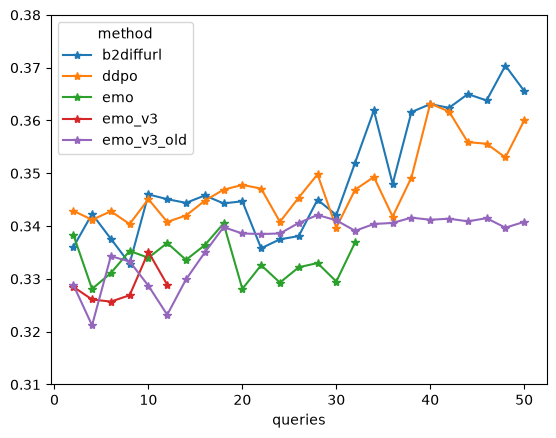

In [159]:
training_eval_df, eval_df = get_metrics()

import matplotlib.pyplot as plt

temp_eval_df = eval_df[eval_df['score'] == 'clip_reward']
temp_eval_df = temp_eval_df[temp_eval_df['method'].isin(list(set(baselines)-set(["dpok_old"])))]
eval_summary = temp_eval_df.pivot_table(
    index=['method', 'score'],
    columns='epoch',
    values='value',
)
# eval_summary.T.iloc[:, 0].plot()
# plt.title("Bert Reward")
# plt.show()
# eval_summary.T.iloc[:, 1].plot()
# plt.title("Clip Reward")
# plt.show()

transposed_eval_summary = eval_summary.T
transposed_eval_summary = transposed_eval_summary.reset_index().droplevel(level=1, axis=1)
# transposed_eval_summary[transposed_eval_summary.index.isin([2]+list(range(0, 50, 5)))].rolling(window=2).mean().round(3).plot(marker='o')
transposed_eval_summary['queries'] = transposed_eval_summary['epoch'].astype(int)#*256
transposed_eval_summary.pivot_table(
    index='queries',
    values=['b2diffurl', 'ddpo', "emo_v3_old", "emo_v3", "emo"],
).round(4).rolling(window=1).mean().plot(marker='*', ylim=(0.31, 0.38)) #.iloc[lambda x: np.arange(len(x)) % 5 < 3]

<Axes: xlabel='epoch'>

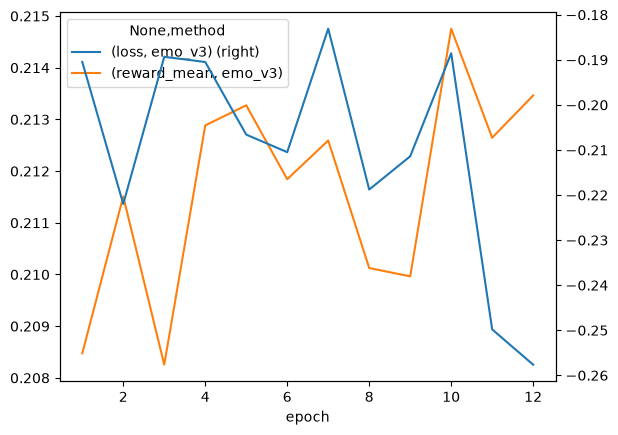

In [160]:
# cols = ['advantage_mean', 'approx_kl', 'current_reward_mean', 'current_reward_std', 'epoch', 'loss', 'parameter_update_norm_mean',
#     'raw_reward_mean', 'raw_reward_std', 'replay_reward_mean',
#     'replay_reward_std', 'reward_mean', 'reward_std', 'selected_samples', 'skipped_updates','method']
# training_eval_df = training_eval_df[cols]
method = "emo_v3"
_training_eval_df = training_eval_df[training_eval_df['method'].isin([method])]
_training_eval_df.pivot_table(
    index='epoch',
    columns='method',
    values=['reward_mean', 'loss']
).round(6).rolling(window=1).mean().plot(kind='line', secondary_y=[('loss', method)])

In [215]:
training_eval_df.columns

Index(['advantage_mean', 'advantage_std', 'approx_kl', 'clip_frac',
       'current_reward_mean', 'current_reward_std', 'early_stopped', 'epoch',
       'grad_norm_pre_clip_max', 'grad_norm_pre_clip_mean', 'learning_rate',
       'log_ratio_percentiles', 'loss', 'parameter_update_norm_mean',
       'raw_reward_mean', 'raw_reward_std', 'replay_reward_mean',
       'replay_reward_std', 'replay_samples', 'reward_by_prompt_category',
       'reward_mean', 'reward_std', 'selected_samples', 'skipped_updates',
       'timestep_clip_frac', 'timestep_kl', 'method', 'entropy',
       'grad_norm_mean', 'importance_ratio', 'policy_loss',
       'replay_source_epoch', 'reward_scale', 'seed', 'soft_q_mean', 'beta',
       'entropy_bonus', 'branch_start_idx', 'interval_steps', 'mean_pair_gap',
       'mean_reward', 'kl_loss', 'transition_kl'],
      dtype='str')